# Pha T — Buoc 1: Tong hop ket qua chinh (khong tinh toan lai tu dau)

Doc + gop du lieu DA CO SAN tu Pha R/R2 (72.000 + 28.800 phep do) va Pha S (du lieu that Fantasia+Apnea-ECG da qua kiem dinh) thanh 1 bo ket qua chinh cho ban thao. Khong chay lai grid, khong train lai, khong chay lai pipeline tien xu ly.

**RANG BUOC QUAN TRONG:** `HybridTEEstimator` (Pha T.2) CHI duoc validate tren du lieu TONG HOP (N=[10,20,30,50,100,200]). Cua so du lieu THAT (Fantasia/Apnea-ECG) luon co N=120 (30s x 4Hz) >> threshold_n=50, nen Hybrid se LUON chon Amortized o do - nhung Amortized da biet cho TE am/vo nghia tren du lieu that (lech chuan tren tin hieu dao dong - xem docs/PHASE_S_REPORT.md muc 5.5). **Vi vay nhanh du lieu that duoi day CHI dung KSG** (da la ket qua chinh thuc PASS cua Pha S), KHONG ap Hybrid/Amortized.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.evaluation.sanity_check import bidirectional_te_per_record, run_sanity_check_per_record
from pqrst.baselines.ksg import KSGTEEstimator

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES = BASE / 'results' / 'tables'
FIGURES = BASE / 'results' / 'figures'

## 1. Dữ liệu tổng hợp: bảng tổng hợp 5 estimator × 2 loại dữ liệu

`phase_t_hybrid_comparison.csv` (từ Pha T.2) đã có sẵn đủ 5 estimator (KSG/Binning/Symbolic/Amortized/Hybrid) × 2 loại dữ liệu (linear/periodic) × 6 N — dùng trực tiếp, không cần gộp lại từ 2 file gốc.

In [2]:
main_table = pd.read_csv(TABLES / 'phase_t_hybrid_comparison.csv')
print(f'Tong so dong: {len(main_table)}')
print(main_table.groupby(['dataset', 'estimator']).size())

summary = main_table.groupby(['dataset', 'estimator', 'n_samples'])[['bias', 'variance', 'mse']].mean().reset_index()
summary.to_csv(TABLES / 'phase_t_main_synthetic_summary.csv', index=False)
print(f"\nDa luu: {TABLES / 'phase_t_main_synthetic_summary.csv'}")
summary.head(10)

Tong so dong: 690
dataset   estimator
linear    Amortized    90
          Binning      90
          Hybrid       90
          KSG          90
          Symbolic     90
periodic  Amortized    48
          Binning      48
          Hybrid       48
          KSG          48
          Symbolic     48
dtype: int64

Da luu: D:\SPARC Lab\PQRST\results\tables\phase_t_main_synthetic_summary.csv


,dataset,estimator,n_samples,bias,variance,mse
0,linear,Amortized,10,-0.065133,0.011680,0.018054
1,linear,Amortized,20,-0.056311,0.006386,0.011221
2,linear,Amortized,30,-0.052946,0.004208,0.008582
3,linear,Amortized,50,-0.049498,0.002593,0.006527
4,linear,Amortized,100,-0.045228,0.001347,0.004823
5,linear,Amortized,200,-0.044321,0.000673,0.003917
6,linear,Binning,10,0.330519,0.023339,0.143296
7,linear,Binning,20,0.594066,0.016417,0.381001
8,linear,Binning,30,0.696500,0.015014,0.512329
9,linear,Binning,50,0.719721,0.014069,0.543848


## 2. Hình gộp: variance theo N, linear vs periodic, đủ 5 estimator

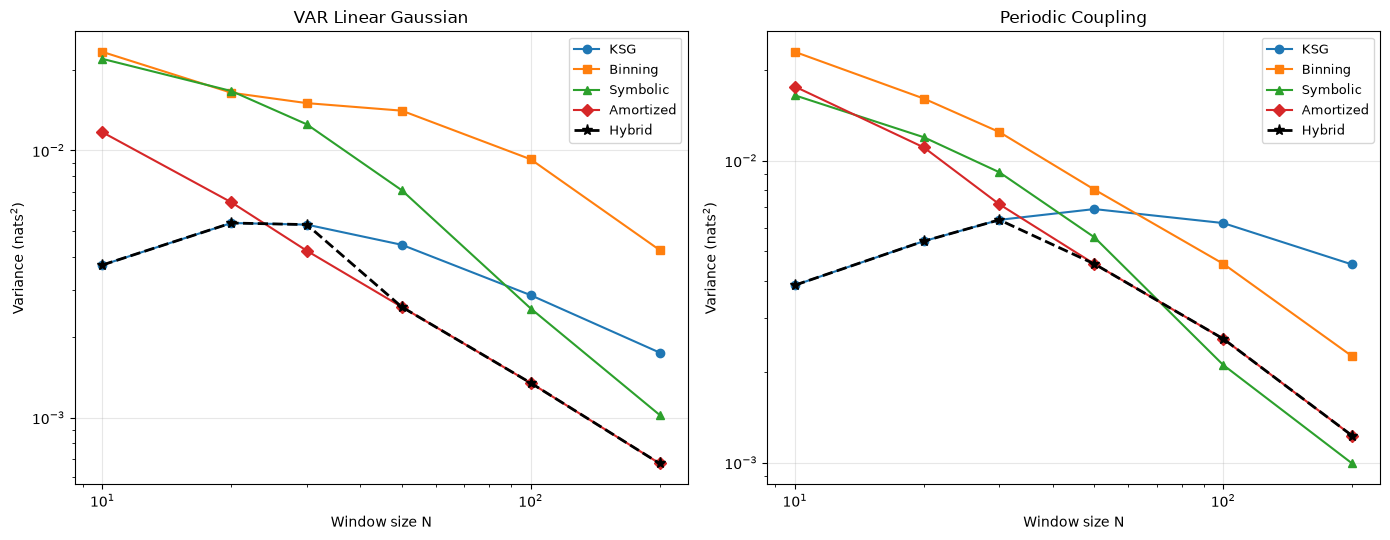

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
colors = {'KSG': 'tab:blue', 'Binning': 'tab:orange', 'Symbolic': 'tab:green',
          'Amortized': 'tab:red', 'Hybrid': 'black'}
styles = {'KSG': '-o', 'Binning': '-s', 'Symbolic': '-^', 'Amortized': '-D', 'Hybrid': '--*'}

for ax, (ds_name, ds_title) in zip(axes, [('linear', 'VAR Linear Gaussian'), ('periodic', 'Periodic Coupling')]):
    sub = summary[summary['dataset'] == ds_name]
    for est in ['KSG', 'Binning', 'Symbolic', 'Amortized', 'Hybrid']:
        est_data = sub[sub['estimator'] == est].groupby('n_samples')['variance'].mean().reset_index()
        ax.plot(est_data['n_samples'], est_data['variance'], styles.get(est, '-o'),
                color=colors.get(est), label=est, linewidth=2 if est == 'Hybrid' else 1.5,
                markersize=8 if est == 'Hybrid' else 6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Window size N')
    ax.set_ylabel('Variance (nats$^2$)')
    ax.set_title(ds_title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / 'phase_t_main_variance_vs_n.png', dpi=120)
plt.show()

## 3. Dữ liệu THẬT: KSG trên Fantasia + Apnea-ECG gộp (chỉ đọc lại, không tính mới)

Nạp lại đúng cửa sổ đã lưu từ Pha S (notebook 02c + 05), gọi lại đúng hàm đã dùng ở đó, rồi đối chiếu với số đã công bố trong `PHASE_S_REPORT.md` mục 5.4 — nếu lệch, dừng và báo rõ, không tự sửa số nào.

In [4]:
est_ksg = KSGTEEstimator()

fantasia_dir = BASE / 'data' / 'processed' / 'fantasia'
fantasia_quality = pd.read_csv(fantasia_dir / 'quality_report.csv')
fantasia_passed = fantasia_quality.loc[fantasia_quality['verdict'] == 'PASS', 'record_id'].tolist()

records = {}
for rid in fantasia_passed:
    w_rr_to_resp = load_corpus(str(fantasia_dir / (rid + '_fwd.npz')))
    w_resp_to_rr = load_corpus(str(fantasia_dir / (rid + '_bwd.npz')))
    records[f'fantasia_{rid}'] = (w_resp_to_rr, w_rr_to_resp)

# Cua so Apnea-ECG khong duoc luu san (khac Fantasia) - doc lai tu dau qua
# dung pipeline cua notebook 05, dung config mac dinh (grid_fs=4, window=30s).
import yaml, wfdb
from pqrst.data.real.cardiac import rr_from_beat_annotations, interpolate_rr
from pqrst.data.real.respiration import preprocess_respiration, bandpass_filter
from pqrst.data.real.sync import align_to_common_grid, sync_and_window
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'preprocessing.yaml', encoding='utf-8'))

apnea_dir = BASE / 'data' / 'processed' / 'apnea-ecg'
apnea_quality = pd.read_csv(apnea_dir / 'quality_report.csv')
apnea_passed = apnea_quality[apnea_quality['verdict'] == 'PASS']
ann_dir = BASE / 'data' / 'raw' / 'apnea-ecg'
for _, row in apnea_passed.iterrows():
    rid = row['record_id']
    ann = wfdb.rdann(str(ann_dir / rid), 'qrs')
    beat_times = (ann.sample / 100.0)[np.array([s == 'N' for s in ann.symbol])]
    t_rr, rr = rr_from_beat_annotations(beat_times, exclude_ectopic=True,
                                         threshold_ratio=cfg['cardiac']['ectopic_threshold_ratio'])
    t_grid_rr, rr_grid = interpolate_rr(t_rr, rr, grid_fs=cfg['grid_fs'])
    rr_filt = bandpass_filter(rr_grid, cfg['grid_fs'], tuple(cfg['respiration']['bandpass_hz']))
    resp_rec = wfdb.rdrecord(str(ann_dir / (rid + 'r')))
    resp_sig = resp_rec.p_signal[:, resp_rec.sig_name.index('Resp C')]
    t_resp, resp_grid = preprocess_respiration(resp_sig, fs=resp_rec.fs, grid_fs=cfg['grid_fs'],
                                                bandpass=tuple(cfg['respiration']['bandpass_hz']))
    rr_al, resp_al = align_to_common_grid(t_grid_rr, rr_filt, t_resp, resp_grid, grid_fs=cfg['grid_fs'])
    w_rr_to_resp = sync_and_window(rr_al, resp_al, grid_fs=cfg['grid_fs'], window_seconds=cfg['window_seconds'])
    w_resp_to_rr = sync_and_window(resp_al, rr_al, grid_fs=cfg['grid_fs'], window_seconds=cfg['window_seconds'])
    records[f'apnea_{rid}'] = (w_resp_to_rr, w_rr_to_resp)

print(f'Tong so ban ghi (Fantasia + Apnea-ECG): {len(records)}')

per_record = bidirectional_te_per_record(records, est_ksg)
fwd_all = [v['te_forward'] for v in per_record.values()]
bwd_all = [v['te_backward'] for v in per_record.values()]
res_real = run_sanity_check_per_record(fwd_all, bwd_all, n_bootstrap=cfg['n_bootstrap'], seed=cfg['seed'])

print(f"N={res_real['n_records']}, TE(resp->tim)={res_real['te_forward_mean']:.4f}, "
      f"TE(tim->resp)={res_real['te_backward_mean']:.4f}")
print(f"CI hieu 95%: [{res_real['ci_difference'][0]:.4f}, {res_real['ci_difference'][1]:.4f}]")
print(f"Wilcoxon p={res_real['wilcoxon_p']:.4f}")

# Doi chieu voi so DA CONG BO trong PHASE_S_REPORT.md muc 5.4 (N=23,
# CI~[0.0057,0.0311], Wilcoxon p~0.0046) - CHI canh bao neu lech, KHONG tu sua.
expected_n, expected_ci_low, expected_ci_high, expected_p = 23, 0.0057, 0.0311, 0.0046
tol = 0.01
matches = (
    res_real['n_records'] == expected_n and
    abs(res_real['ci_difference'][0] - expected_ci_low) < tol and
    abs(res_real['ci_difference'][1] - expected_ci_high) < tol
)
if matches:
    print('\n=== KHOP voi so da cong bo trong PHASE_S_REPORT.md muc 5.4 ===')
else:
    print('\n!!! CANH BAO: LECH so voi PHASE_S_REPORT.md muc 5.4 - kiem tra lai truoc khi dung, KHONG tu sua so nao !!!')
    print(f"   Ky vong: N={expected_n}, CI=[{expected_ci_low},{expected_ci_high}], p~{expected_p}")

Tong so ban ghi (Fantasia + Apnea-ECG): 23


Sanity check (theo ban ghi, N=23) PASSED: TE forward > TE backward ro ret, CI hieu so khong chua 0, Wilcoxon p=0.0046.
N=23, TE(resp->tim)=0.1175, TE(tim->resp)=0.0996
CI hieu 95%: [0.0057, 0.0311]
Wilcoxon p=0.0046

=== KHOP voi so da cong bo trong PHASE_S_REPORT.md muc 5.4 ===


## 4. Bảng tổng kết cuối: tiêu chí thoát cả 4 pha (P, Q, R/R2, S) + T.1

In [5]:
final_summary = pd.DataFrame([
    {'Pha': 'P', 'Tieu chi': 'Baseline bias thap tren du lieu co ground-truth', 'Ket qua': 'DAT (KSG bias<=0.03 nat moi config)'},
    {'Pha': 'Q', 'Tieu chi': 'Sai so MI < 20%', 'Ket qua': 'DAT (7.6%, hoac 2.86% neu trung binh post-convergence)'},
    {'Pha': 'R', 'Tieu chi': 'Thang KSG+Symbolic o >=70% o N<30', 'Ket qua': 'CHUA DAT (9/30) - nhung thang ro tu N>=30, diem giao cat on dinh qua 3 kiem dinh'},
    {'Pha': 'S', 'Tieu chi': 'Sanity check TE dat tren >=1 bo du lieu that', 'Ket qua': 'DAT (KSG, Fantasia+Apnea-ECG gop N=23, CI hoan toan duong)'},
    {'Pha': 'T.1', 'Tieu chi': 'Tong hop ket qua chinh + xac nhan lai so real-data', 'Ket qua': 'DAT (xem muc 3 tren)' if matches else 'CANH BAO - xem muc 3'},
])
final_summary.to_csv(TABLES / 'phase_t_exit_criteria_summary.csv', index=False)
final_summary

,Pha,Tieu chi,Ket qua
0,P,Baseline bias thap tren du lieu co ground-truth,DAT (KSG bias<=0.03 nat moi config)
1,Q,Sai so MI < 20%,"DAT (7.6%, hoac 2.86% neu trung binh post-conv..."
2,R,Thang KSG+Symbolic o >=70% o N<30,"CHUA DAT (9/30) - nhung thang ro tu N>=30, die..."
3,S,Sanity check TE dat tren >=1 bo du lieu that,"DAT (KSG, Fantasia+Apnea-ECG gop N=23, CI hoan..."
4,T.1,Tong hop ket qua chinh + xac nhan lai so real-...,DAT (xem muc 3 tren)
